In [401]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import librosa.display
import utility
import os

In [402]:
# audio reading
# audio_file = "./template_mfcc/origin/9.wav"
audio_file = "./template_mfcc/luo_wav/9hao_luo.wav"
# audio_file = "./template_mfcc/hong_wav/1hong.wav"
file_name = os.path.splitext(os.path.basename(audio_file))[0]
print(file_name)

x, fs = librosa.load(audio_file, sr=16000) # fs = 16khz


9hao_luo


In [ ]:
# power threshold
# start_idx = np.argmax(np.abs(x) > 0.003)
# end_idx = len(x) - np.argmax(np.abs(x)[::-1] > 0.003)
# x = x[start_idx:end_idx]
# x, idx = librosa.effects.trim(x, top_db=30)

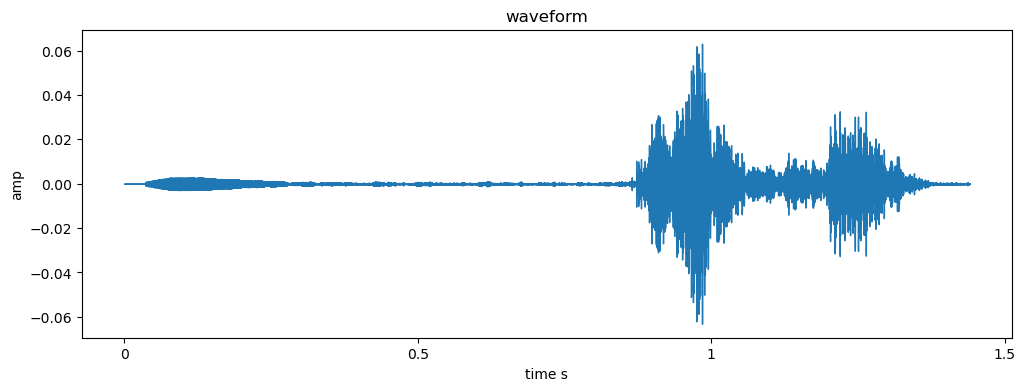

In [404]:
# visualization for origin signal
plt.figure(figsize=(12, 4))
librosa.display.waveshow(x, sr=fs)
plt.title("waveform")
plt.xlabel("time s")
plt.ylabel("amp")
plt.show()

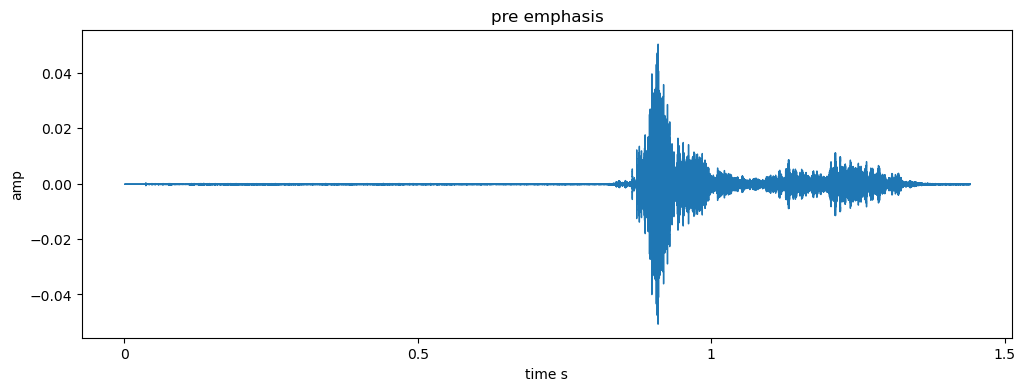

In [405]:
# pre-emphasis
alpha = 0.97
x = np.append(x[0], x[1:] - alpha * x[:-1])

plt.figure(figsize=(12,  4))
librosa.display.waveshow(x, sr=fs)
plt.title("pre emphasis")
plt.xlabel("time s")
plt.ylabel("amp")
plt.show()


In [406]:
# frame blocking
frame_length = int(0.025 * fs)  # 25ms
hop_length = int(0.010 * fs)    # 10ms
num_frames = int((len(x) - frame_length) / hop_length)

frames = np.zeros((num_frames, frame_length))

# hamming
win_hamming = 0.54 - 0.46 * np.cos(2 * np.pi * np.arange(frame_length) / (frame_length - 1))

for m in range(num_frames):
    start = m * hop_length
    frames[m, :] = x[start:start + frame_length] * win_hamming
print(frames.shape)



(141, 400)


In [407]:
# FFT
n_fft = 512
X = np.fft.rfft(frames, n=n_fft, axis=1)
stps = (1.0 / n_fft) * np.abs(X)**2
print(stps.shape)

(141, 257)


In [408]:
# mel filter bank
num_mel = 26
mel_bank = utility.mel_bank(num_mel, n_fft, sr=fs)
print(mel_bank.shape)

Emel = np.dot(stps, mel_bank.T)
print(Emel.shape)

logEmel = np.log(Emel + 1e-10)


(26, 257)
(141, 26)


In [409]:
# DCT
mfcc_out = 12
dct_matrix = utility.dct_matrix(num_mel, mfcc_out)
mfcc = np.dot(logEmel, dct_matrix)
mfcc = utility.CMVN(mfcc)
delta = utility.compute_delta(mfcc)
delta2 = utility.compute_delta(delta)
features = np.hstack([mfcc, delta, delta2])
print(features.shape)

(141, 36)


In [410]:
# mfcc visulaization


In [411]:
# save template
# np.savetxt(f"./template_mfcc/{file_name}_mfcc.csv", features, delimiter=",")

In [412]:
# save object
np.savetxt(f"{file_name}_mfcc.csv", features, delimiter=",")